# Midterm
- John Laffey
- PID: 5681808
- Email: jo407341@ucf.edu
- Date: 03/10/2026
- Midterm

In [116]:
import pandas as pd
import pprint
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
df = pd.read_csv('../data/LoanStats3a.csv', low_memory=False)
cols = df.columns.to_list()
pprint.pprint(cols) 
df.head()
# Note to prof -> I used a lambda for formatting any series where applicable. It's similar to format! in rust so it looks cleaner to read.

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 'dti_joint',
 'verification_status_joint',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,5000.0,5000.0,4975.0,36 months,10.65%,162.87,B,B2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,2500.0,2500.0,2500.0,60 months,15.27%,59.83,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,2400.0,2400.0,2400.0,36 months,15.96%,84.33,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,10000.0,10000.0,10000.0,36 months,13.49%,339.31,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,3000.0,3000.0,3000.0,60 months,12.69%,67.79,B,B5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [117]:
# Question 1 -> use int_rate
stats = df['int_rate'].dropna().str.replace('%', '').astype(float).describe()
formatted_stats = stats.apply(lambda x: f"{x:.2f}") 
print(formatted_stats)



count    42535.00
mean        12.17
std          3.71
min          5.42
25%          9.63
50%         11.99
75%         14.72
max         24.59
Name: int_rate, dtype: str


In [118]:
# Question 2 -> use 'term' They output as mm months (ran as series before manipulation)
term = df['term'].dropna().str.replace(' months', '').astype(int).describe()
formatted_term = term.apply(lambda x: f"{x:.2f}")
print(formatted_term)
# minimum -> 36 months
# max -> 60 months
# mean -> 42.2 months

count    42535.00
mean        42.21
std         10.51
min         36.00
25%         36.00
50%         36.00
75%         60.00
max         60.00
Name: term, dtype: str


In [119]:
# Question 3 -> use 'loan_amnt'
loan_amnt = df['loan_amnt'].dropna().describe()
formatted_loan_amnt = loan_amnt.apply(lambda x: f"{x:.2f}")
print(formatted_loan_amnt)
# min -> 500
# max -> 35000
# mean -> 11089.72

count    42535.00
mean     11089.72
std       7410.94
min        500.00
25%       5200.00
50%       9700.00
75%      15000.00
max      35000.00
Name: loan_amnt, dtype: str


In [120]:
# Question 4 -> use 'purpose'
unique_purposes = df['purpose'].dropna().unique().tolist()
pprint.pprint(unique_purposes)
# List of all unique loan purposes

['credit_card',
 'car',
 'small_business',
 'other',
 'wedding',
 'debt_consolidation',
 'home_improvement',
 'major_purchase',
 'medical',
 'moving',
 'vacation',
 'house',
 'renewable_energy',
 'educational']


In [121]:
# Question 5 -> use 'home_ownership' Not sure if I overanswered this, but it made sense to me.

home_ownership_series = df['home_ownership'].dropna()
unique_home_ownership_values = home_ownership_series.unique().tolist()
print('Unique Home Ownership Values: ', unique_home_ownership_values, '\n')
print('Total analysis count: ', home_ownership_series.count(), '\n')
home_ownership_value_counts = home_ownership_series.value_counts(normalize=True)
formatted_value_counts_hown = (home_ownership_value_counts * 100).apply(lambda x: f"{x:.2f}%")
print('Home Ownership Value Counts:\n\n', formatted_value_counts_hown)
# Unique Values printed as list
# Only a total of 7.64% actually own their home, 47.45% rent, 44.57% have a mortgage, and 0.32% fall as other, with NONE as 0.02%

Unique Home Ownership Values:  ['RENT', 'OWN', 'MORTGAGE', 'OTHER', 'NONE'] 

Total analysis count:  42535 

Home Ownership Value Counts:

 home_ownership
RENT        47.45%
MORTGAGE    44.57%
OWN          7.64%
OTHER        0.32%
NONE         0.02%
Name: proportion, dtype: str


In [122]:
# Question 6 -> use 'addr_state'
states = df['addr_state'].dropna()
states_unique = states.sort_values(ascending=True).unique().tolist()
print("States in dataset: ")
pprint.pprint(states_unique)
print('\n\n')
states_value_count = (states.value_counts(normalize=True) * 100)
formatted_states_value_count = states_value_count.apply(lambda x: f"{x:.2f}%")
print('States Value Count as %')
print(formatted_states_value_count)
# Note -> Most 5 popular states in order 1 to 5 are CA (17.47%), NY (9.56%), FL (7.30%), TX (6.85%), NJ (4.67%), but you can see full list below.

States in dataset: 
['AK',
 'AL',
 'AR',
 'AZ',
 'CA',
 'CO',
 'CT',
 'DC',
 'DE',
 'FL',
 'GA',
 'HI',
 'IA',
 'ID',
 'IL',
 'IN',
 'KS',
 'KY',
 'LA',
 'MA',
 'MD',
 'ME',
 'MI',
 'MN',
 'MO',
 'MS',
 'MT',
 'NC',
 'NE',
 'NH',
 'NJ',
 'NM',
 'NV',
 'NY',
 'OH',
 'OK',
 'OR',
 'PA',
 'RI',
 'SC',
 'SD',
 'TN',
 'TX',
 'UT',
 'VA',
 'VT',
 'WA',
 'WI',
 'WV',
 'WY']



States Value Count as %
addr_state
CA    17.47%
NY     9.56%
FL     7.30%
TX     6.85%
NJ     4.67%
IL     3.93%
PA     3.88%
GA     3.53%
VA     3.50%
MA     3.38%
OH     3.12%
MD     2.64%
AZ     2.19%
WA     2.09%
CO     2.01%
NC     1.95%
CT     1.92%
MI     1.87%
MO     1.80%
MN     1.53%
NV     1.24%
WI     1.21%
SC     1.15%
AL     1.14%
OR     1.10%
LA     1.08%
KY     0.84%
OK     0.75%
KS     0.70%
UT     0.65%
AR     0.61%
DC     0.53%
RI     0.49%
NM     0.48%
NH     0.44%
WV     0.44%
HI     0.43%
DE     0.32%
MT     0.23%
WY     0.20%
AK     0.20%
SD     0.16%
VT     0.13%
TN     0.08%
MS     0.06%
IN     

In [123]:
# Question 7  -> Use 'finished_loans' (prolly a good predictor since it's paid off or not)
# Choose some features loan amount, debt to income, open_account, revol util, interest rate, annual_inc, inq_last_6mths

features = ['int_rate', 'loan_amnt', 'dti', 'open_acc', 'revol_util', 'annual_inc', 'inq_last_6mths']
categorical_features = ['grade', 'term']
columns_to_keep = features + categorical_features + ['loan_status']

completed_loans = df[columns_to_keep].dropna(subset=['loan_status']).copy()
# unique_loan_status_values = completed_loans['loan_status'].unique().tolist()
# print(unique_loan_status_values)

status_map = {
    'Fully Paid': 1,
    'Does not meet the credit policy. Status:Fully Paid': 1,
    'Charged Off': 0,
    'Does not meet the credit policy. Status:Charged Off': 0
}

# Mapping grades to numbers to help the model
grade_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}

# Mapping term to numbers
term_map = {' 36 months': 36, ' 60 months': 60}

completed_loans['target'] = completed_loans['loan_status'].map(status_map)
completed_loans['grade'] = completed_loans['grade'].map(grade_map)
completed_loans['term'] = completed_loans['term'].map(term_map)
print(completed_loans['loan_status'].value_counts())


# Clean some of the data to flt64
completed_loans['int_rate'] = completed_loans['int_rate'].astype(str).str.replace('%', '').astype(float)
completed_loans['revol_util'] = completed_loans['revol_util'].astype(str).str.replace('%', '').astype(float)

X = completed_loans[features + categorical_features]
y = completed_loans['target']

# Handle any data that may be missing
X = X.fillna(X.median())

# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=16)

# Fit scaler to the training & test data.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the model
print('Training model... Prolly gonna be a min')
log_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=16)
log_model.fit(X_train_scaled, y_train)

# Predict & Evaluate
y_pred = log_model.predict(X_test_scaled)
print('Evaluation \n')
print(f'Accuracy: {accuracy_score(y_test, y_pred)* 100:.2f}%\n')
print()
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred), '\n')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred))

# Model Analysis
# I started with a few features to add to the model and had horrid accuracy. I think based on all of the context in this csv there isn't really a great indicator
# for who is going to pay a loan or not pay a loan back except probably annual income
# # but the final model achieved 64.36% accuracy. I think part of the problem is that most of the data in this dataset 
# (upon analyzing as i did value counts shows most loans are fully paid off.)
# So the model has more context in what makes a loan fully paid. But the inverse or differences in those values 
# don't always make valueable predictors in if someone will not pay off a loan which 
# made this problem extremely tricky.


loan_status
Fully Paid                                             34116
Charged Off                                             5670
Does not meet the credit policy. Status:Fully Paid      1988
Does not meet the credit policy. Status:Charged Off      761
Name: count, dtype: int64
Training model... Prolly gonna be a min
Evaluation 

Accuracy: 64.36%


Confusion Matrix:
[[ 793  464]
 [2568 4682]] 


Classification Report:
              precision    recall  f1-score   support

           0       0.24      0.63      0.34      1257
           1       0.91      0.65      0.76      7250

    accuracy                           0.64      8507
   macro avg       0.57      0.64      0.55      8507
weighted avg       0.81      0.64      0.69      8507



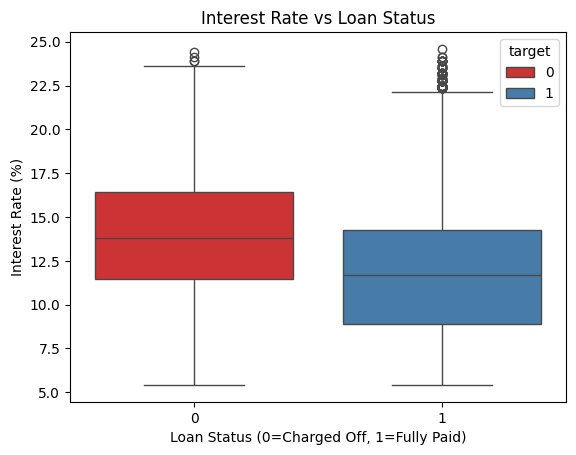

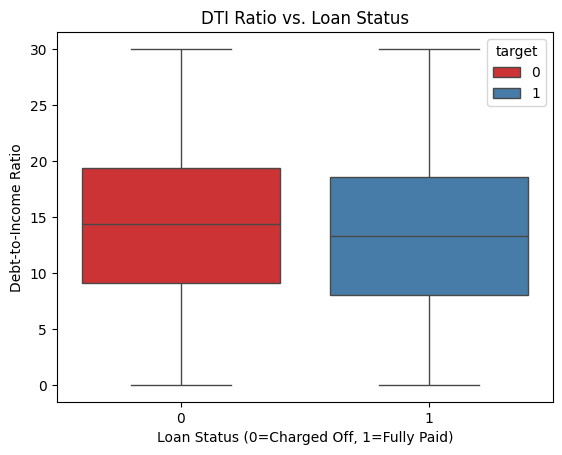

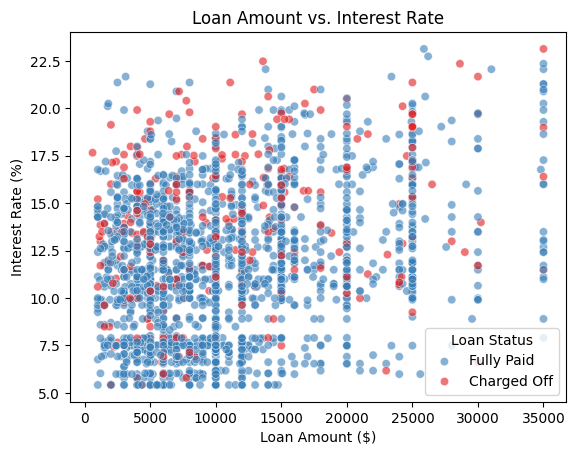

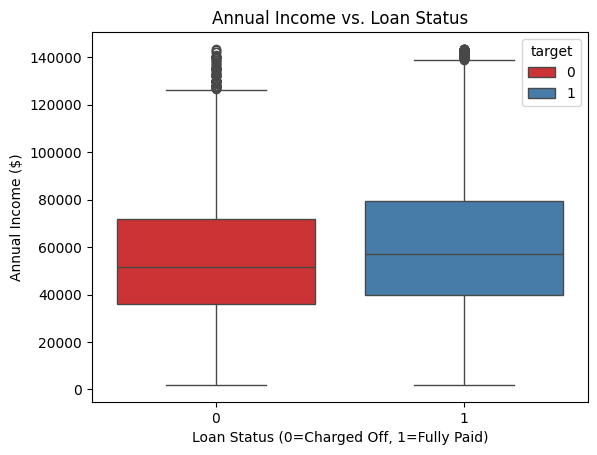

In [ ]:
# Question 8 -> Visualize the data
# Interest Rate vs Target
# Shows Charged off loans generally have larger interest rates
# Sorry was crunched for time so didn't make these look too flashy.

sns.boxplot(x='target', y='int_rate', data=completed_loans, palette='Set1', hue='target')
plt.title('Interest Rate vs Loan Status')
plt.xlabel('Loan Status (0=Charged Off, 1=Fully Paid)')
plt.ylabel('Interest Rate (%)')
plt.show()

# DTI Ratio vs Target
# Correlates with slightly higher default risk
sns.boxplot(x='target', y='dti', data=completed_loans, palette='Set1', hue='target')
plt.title('DTI Ratio vs. Loan Status')
plt.xlabel('Loan Status (0=Charged Off, 1=Fully Paid)')
plt.ylabel('Debt-to-Income Ratio')
plt.show()

# Loan Amount vs Interest Rate
# Shows higher interest rates will usually have more charge offs.
sample_data = completed_loans.sample(2000, random_state=16)
sns.scatterplot(x='loan_amnt', y='int_rate', hue='target', data=sample_data, alpha=0.6, palette='Set1')
plt.title('Loan Amount vs. Interest Rate')
plt.xlabel('Loan Amount ($)')
plt.ylabel('Interest Rate (%)')
plt.legend(title='Loan Status', labels=['Fully Paid', 'Charged Off'])
plt.show()

# Annual Incom vs Target
# Shows higher annual income will 
income_limit = completed_loans['annual_inc'].quantile(0.95) # filter out extremes
filtered_income = completed_loans[completed_loans['annual_inc'] < income_limit]
sns.boxplot(x='target', y='annual_inc', data=filtered_income, palette='Set1', hue='target')
plt.title('Annual Income vs. Loan Status')
plt.xlabel('Loan Status (0=Charged Off, 1=Fully Paid)')
plt.ylabel('Annual Income ($)')
plt.show()


